# Pronoun exploration

Exploratory look at first-person framing ("I" vs. "we") in the convention
corpus. This notebook works from the **canonical feature table**
`../data/pronoun_counts.csv` produced by `src/build_i_vs_we.py`, and uses
the same 215-word cutoff as the analysis in `hypothesis_testing.ipynb`, so
the numbers here match the paper. This is descriptive EDA; the formal
permutation tests and confidence intervals live in
`hypothesis_testing.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORD_CUTOFF = 215
PARTY_COLORS = {"Democratic": "#3498db", "Republican": "#e74c3c"}

df_all = pd.read_csv("../data/pronoun_counts.csv")
print(f"Loaded {len(df_all)} speeches (pre-filter)")
print("Columns:", list(df_all.columns))
df_all.head()

Loaded 1800 speeches (pre-filter)
Columns: ['speech_id', 'speaker', 'party', 'year', 'night', 'timestamp', 'word_count', 'source_file', 'source', 'i_count', 'we_count', 'i_rate', 'we_rate', 'collective_gap']


,speech_id,speaker,party,year,night,timestamp,word_count,source_file,source,i_count,we_count,i_rate,we_rate,collective_gap
0,1,Rod O'connor,Democratic,2004,1,00:01:37,400,www_c_span_transcripts2004-democratic-national...,CSPAN,4,8,10.00,20.00,10.00
1,2,Alice Huffman,Democratic,2004,1,00:04:39,384,www_c_span_transcripts2004-democratic-national...,CSPAN,4,5,10.42,13.02,2.60
2,3,Bill Richardson,Democratic,2004,1,00:06:08,506,www_c_span_transcripts2004-democratic-national...,CSPAN,4,4,7.91,7.91,0.00
3,4,Edward McElroy,Democratic,2004,1,00:08:05,397,www_c_span_transcripts2004-democratic-national...,CSPAN,1,9,2.52,22.67,20.15
4,5,Al Gore,Democratic,2004,1,00:09:18,1674,www_c_span_transcripts2004-democratic-national...,CSPAN,36,22,21.51,13.14,-8.37


## Why the 215-word cutoff

Short speeches give unstable per-1,000-word rates: a 40-word floor-yielding
remark with one "I" reads as 25 per 1,000. Below we show that sub-threshold
speeches have systematically inflated, noisier rates — which is why the
analysis filters to speeches of at least 215 words (the geometric-model
derivation is in the paper, §3.2). These rates come straight from the
canonical feature file; we do not recompute them here.

Under 215 words: 537 speeches (29.8%)
  mean i_rate  20.24 | we_rate 18.52
>= 215 words: 1263 speeches
  mean i_rate  16.08 | we_rate 17.60


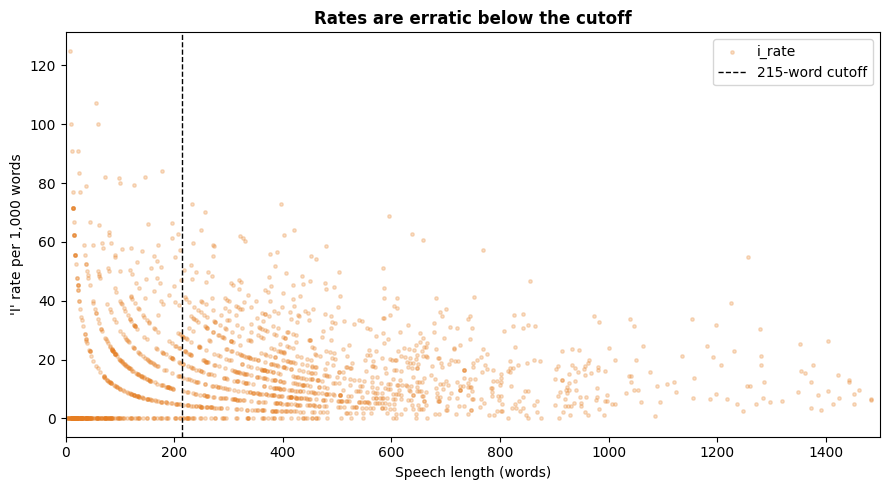

In [2]:
under = df_all[df_all["word_count"] < WORD_CUTOFF]
over  = df_all[df_all["word_count"] >= WORD_CUTOFF]
print(f"Under {WORD_CUTOFF} words: {len(under)} speeches "
      f"({len(under)/len(df_all)*100:.1f}%)")
print(f"  mean i_rate  {under['i_rate'].mean():.2f} | "
      f"we_rate {under['we_rate'].mean():.2f}")
print(f">= {WORD_CUTOFF} words: {len(over)} speeches")
print(f"  mean i_rate  {over['i_rate'].mean():.2f} | "
      f"we_rate {over['we_rate'].mean():.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_all["word_count"], df_all["i_rate"], s=6, alpha=0.25,
           color="#e67e22", label="i_rate")
ax.axvline(WORD_CUTOFF, color="black", ls="--", lw=1,
           label=f"{WORD_CUTOFF}-word cutoff")
ax.set_xlim(0, 1500)
ax.set_xlabel("Speech length (words)")
ax.set_ylabel("'I' rate per 1,000 words")
ax.set_title("Rates are erratic below the cutoff", fontweight="bold")
ax.legend()
plt.tight_layout(); plt.show()

## Definitive corpus (>= 215 words)

Everything below uses the filtered corpus, matching `hypothesis_testing.ipynb`.

In [3]:
df = df_all[df_all["word_count"] >= WORD_CUTOFF].reset_index(drop=True)
print(f"Filtered corpus: {len(df)} speeches")
print(df["party"].value_counts().to_string())
print("\nMean rates by party:")
df.groupby("party")[["i_rate", "we_rate", "collective_gap"]].mean().round(2)

Filtered corpus: 1263 speeches
party
Democratic    786
Republican    477

Mean rates by party:


,i_rate,we_rate,collective_gap
party,,,
Democratic,15.61,18.28,2.67
Republican,16.85,16.49,-0.36


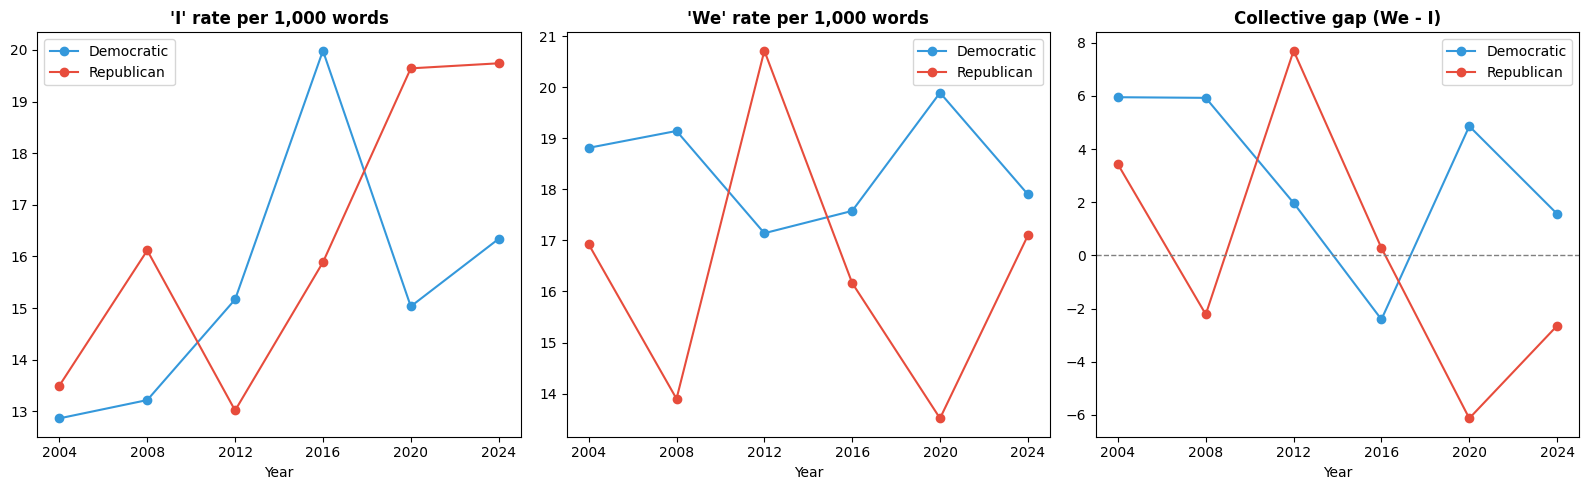

In [4]:
# Year-by-party trends (matches the manuscript's pronoun_trends figure)
year_party = (df.groupby(["year", "party"])[["i_rate", "we_rate", "collective_gap"]]
                .mean().reset_index())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (metric, title) in zip(axes, [
    ("i_rate",         "'I' rate per 1,000 words"),
    ("we_rate",        "'We' rate per 1,000 words"),
    ("collective_gap", "Collective gap (We - I)"),
]):
    for party, color in PARTY_COLORS.items():
        d = year_party[year_party["party"] == party]
        ax.plot(d["year"], d[metric], marker="o", label=party, color=color)
    if metric == "collective_gap":
        ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Year")
    ax.set_xticks(sorted(df["year"].unique())); ax.legend()
plt.tight_layout(); plt.show()

## Incumbency (descriptive)

Collective gap for the incumbent vs. challenger party by cycle. Incumbency
coding follows the paper (2004 Rep, 2008 Rep, 2012 Dem, 2016 Dem, 2020 Rep,
2024 Dem). 2024 is shown for context but is excluded from the formal H2/H2b
tests (see the paper, §3.4).

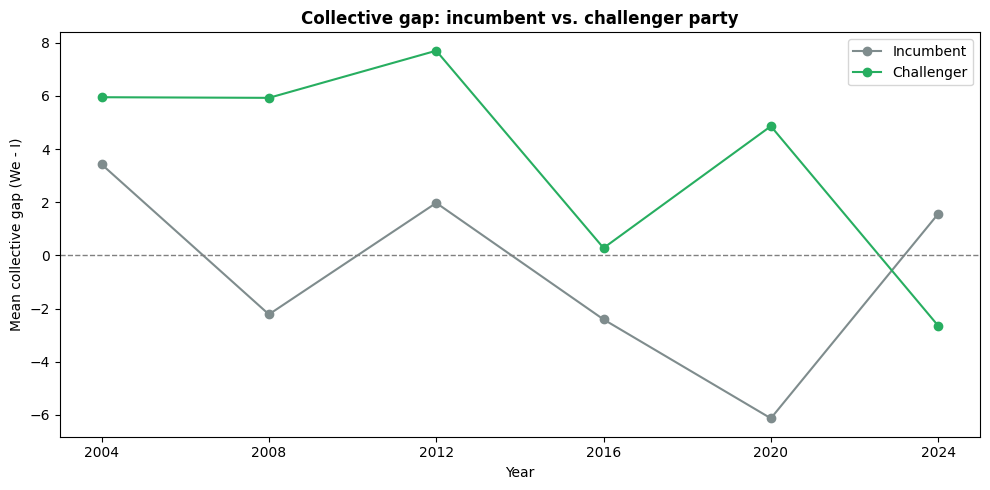

i_rate  we_rate  collective_gap
year role                                       
2004 Challenger   12.86    18.81            5.95
     Incumbent    13.50    16.92            3.42
2008 Challenger   13.22    19.14            5.92
     Incumbent    16.12    13.90           -2.22
2012 Challenger   13.02    20.71            7.70
     Incumbent    15.17    17.14            1.97
2016 Challenger   15.89    16.17            0.28
     Incumbent    19.98    17.58           -2.41
2020 Challenger   15.03    19.89            4.86
     Incumbent    19.64    13.52           -6.13
2024 Challenger   19.74    17.10           -2.64
     Incumbent    16.34    17.90            1.56

In [5]:
incumbent = {2004: "Republican", 2008: "Republican", 2012: "Democratic",
             2016: "Democratic", 2020: "Republican", 2024: "Democratic"}
df["role"] = np.where(df["party"] == df["year"].map(incumbent),
                      "Incumbent", "Challenger")

gap = (df.groupby(["year", "role"])["collective_gap"].mean().reset_index())
fig, ax = plt.subplots(figsize=(10, 5))
for role, color in [("Incumbent", "#7f8c8d"), ("Challenger", "#27ae60")]:
    d = gap[gap["role"] == role]
    ax.plot(d["year"], d["collective_gap"], marker="o", label=role, color=color)
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("Year"); ax.set_ylabel("Mean collective gap (We - I)")
ax.set_title("Collective gap: incumbent vs. challenger party", fontweight="bold")
ax.set_xticks(sorted(df["year"].unique())); ax.legend()
plt.tight_layout(); plt.show()

df.groupby(["year", "role"])[["i_rate", "we_rate", "collective_gap"]].mean().round(2)

## Most "I"-heavy and most "we"-heavy speakers

On the filtered corpus, restricted to speeches of at least 500 words so the
rates are stable.

In [6]:
long = df[df["word_count"] >= 500]
print("Top 10 by 'I' rate:")
print(long.nlargest(10, "i_rate")[["speaker", "year", "party", "i_rate", "word_count"]]
      .to_string(index=False))
print("\nTop 10 by 'we' rate:")
print(long.nlargest(10, "we_rate")[["speaker", "year", "party", "we_rate", "word_count"]]
      .to_string(index=False))

Top 10 by 'I' rate:
         speaker  year      party  i_rate  word_count
   Alice Johnson  2020 Republican   68.91         595
Kayleigh McEnany  2020 Republican   62.70         638
  Maximo Alvarez  2020 Republican   60.79         658
      Dana White  2024 Republican   57.29         768
  Clint Eastwood  2012 Republican   54.89        1257
      Amber Rose  2024 Republican   51.28         585
    D.L. Hughley  2024 Democratic   49.60         504
      Hulk Hogan  2024 Republican   46.78         855
 Lilly Ledbetter  2008 Democratic   44.37         586
      Dana White  2016 Republican   41.50         506

Top 10 by 'we' rate:
             speaker  year      party  we_rate  word_count
Jenna & Barbara Bush  2004 Republican    57.06         701
      Charles Rangel  2004 Democratic    52.33         688
        Mike Johnson  2024 Republican    48.97         919
        Barney Frank  2004 Democratic    48.51         639
        Andrew Cuomo  2016 Democratic    46.53        1483
    Paula 

---
For the formal hypothesis tests (H1, H1b, H2, H2b, and the
nominee/surrogate decomposition), with permutation p-values and bootstrap
confidence intervals, see `hypothesis_testing.ipynb`.